# 00 · The experiment and the plate layout

In this notebook you will:

- read a real, hand-made plate layout workbook and turn it into tidy tables
- see the design of the experiment: 18 conditions, 4 timepoints, 224 wells
- build the **decoder** that says which antibody was imaged in which channel and round
- meet the four biological themes the rest of Part 3 is organised around

:::{note}
This notebook needs **only the layout workbook**, which is in the repository. You can
run it on a laptop, before the big feature table is anywhere near you.
:::

## Why a whole notebook about a spreadsheet

The feature table you will analyse has 4,464 columns with names like
`cells_Intensity_mean_intensity_Texas Red_0`. That name tells you the **channel**
(`Texas Red`) and the **imaging round** (`0`). It does not tell you what was stained.

The antibody is recorded in one place only: the staining sheet of this workbook. Until
you join the two, you have 4,464 anonymous numbers. This notebook makes them meet.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# The course package lives in src/; make it importable from the book directory.
sys.path.insert(0, str(Path.cwd().parents[2] / "src"))

from mcs2026 import layout, panels, plotting

plotting.set_style()
pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 140)

XLSX = Path.cwd().parents[2] / "metadata" / "L_ayout_384_Haralick_Thresholds.xlsx"
XLSX.exists()

True

## The experiment

One 384-well plate, barcode `HNES1_MP_PL_1`.

**HNES1** cells are human naive embryonic stem cells. They were plated, treated with
one of 18 media conditions, fixed at one of four timepoints, and then imaged over **18
rounds** of 4i — iterative indirect immunofluorescence imaging, where the sample is
stained, imaged, the antibodies are eluted, and the cycle repeats. That is how you get
40 markers out of a microscope with three colour channels.

The workbook has four sheets, all describing the same plate:

In [2]:
pd.ExcelFile(XLSX).sheet_names

['MediumLayout', 'StainingLayout', 'LineLayout', 'OtherLayout']

| sheet | what it records |
|---|---|
| `MediumLayout` | the condition in each well, plus the code → compound legend |
| `OtherLayout` | the timepoint in each well |
| `LineLayout` | the cell line in each well |
| `StainingLayout` | **the decoder**: antibody per round per channel |

These are laid out the way a person lays out a plate map: a grid with row letters down
the side and column numbers along the top, a legend off to the right, and a "Notes:"
row at the bottom. There is no header row a parser could use.

`mcs2026.layout` handles that by looking for the *structure* rather than hard-coded
cell addresses — the column holding `A`…`P`, the row holding `1`…`24`, the cell that
says `Conditions`. Insert a row in the spreadsheet and it still works.

## The conditions

In [3]:
conditions = layout.read_conditions(XLSX)
conditions

,condition_code,compound,is_control
0,Cnd1,Cycloheximide,False
1,Cnd2,IGF,False
2,Cnd3,MK-2206,False
3,Cnd4,Wortmannin,False
4,Cnd5,Sapanisertib/INK128,False
5,Cnd6,PF-4708671,False
6,Cnd7,LipidMix,False
7,Cnd8,Glucose,False
8,Cnd9,UCL-TRO-1938,False
9,Cnd10,IL6,False


Sixteen perturbations and two controls. The compounds are not a random panel — they
target specific processes, and that is what makes the analysis in later chapters
testable:

| compounds | what they hit |
|---|---|
| MK-2206, Wortmannin, Sapanisertib/INK128, PF-4708671, IGF | the **PI3K–AKT–mTOR** axis |
| Glucose, LipidMix, MEM AA, UCL-TRO-1938 | **metabolism** |
| Cycloheximide, Geldanamycin | translation and **proteostasis** |
| RA, IL6, PMA, Dorsomorphin, Pd17 | differentiation and other **signaling** |
| **DMSO**, **PBS** | **controls** |

DMSO is the vehicle control: the compounds are dissolved in it, so DMSO-treated wells
tell you what the solvent alone does. Everything later is measured relative to it.

## The wells

In [4]:
wells = layout.read_wells(XLSX)
print(f"{len(wells)} used wells")
wells.head()

224 used wells


,row,column,well,condition_code,timepoint_h,cell_line,compound,is_control
0,B,2,B02,Cnd17,36,CBA,PBS,True
1,B,3,B03,Cnd12,36,CBA,MEM AA,False
2,B,4,B04,Cnd4,36,CBA,Wortmannin,False
3,B,5,B05,Cnd6,36,CBA,PF-4708671,False
4,B,8,B08,Cnd17,48,CBA,PBS,True


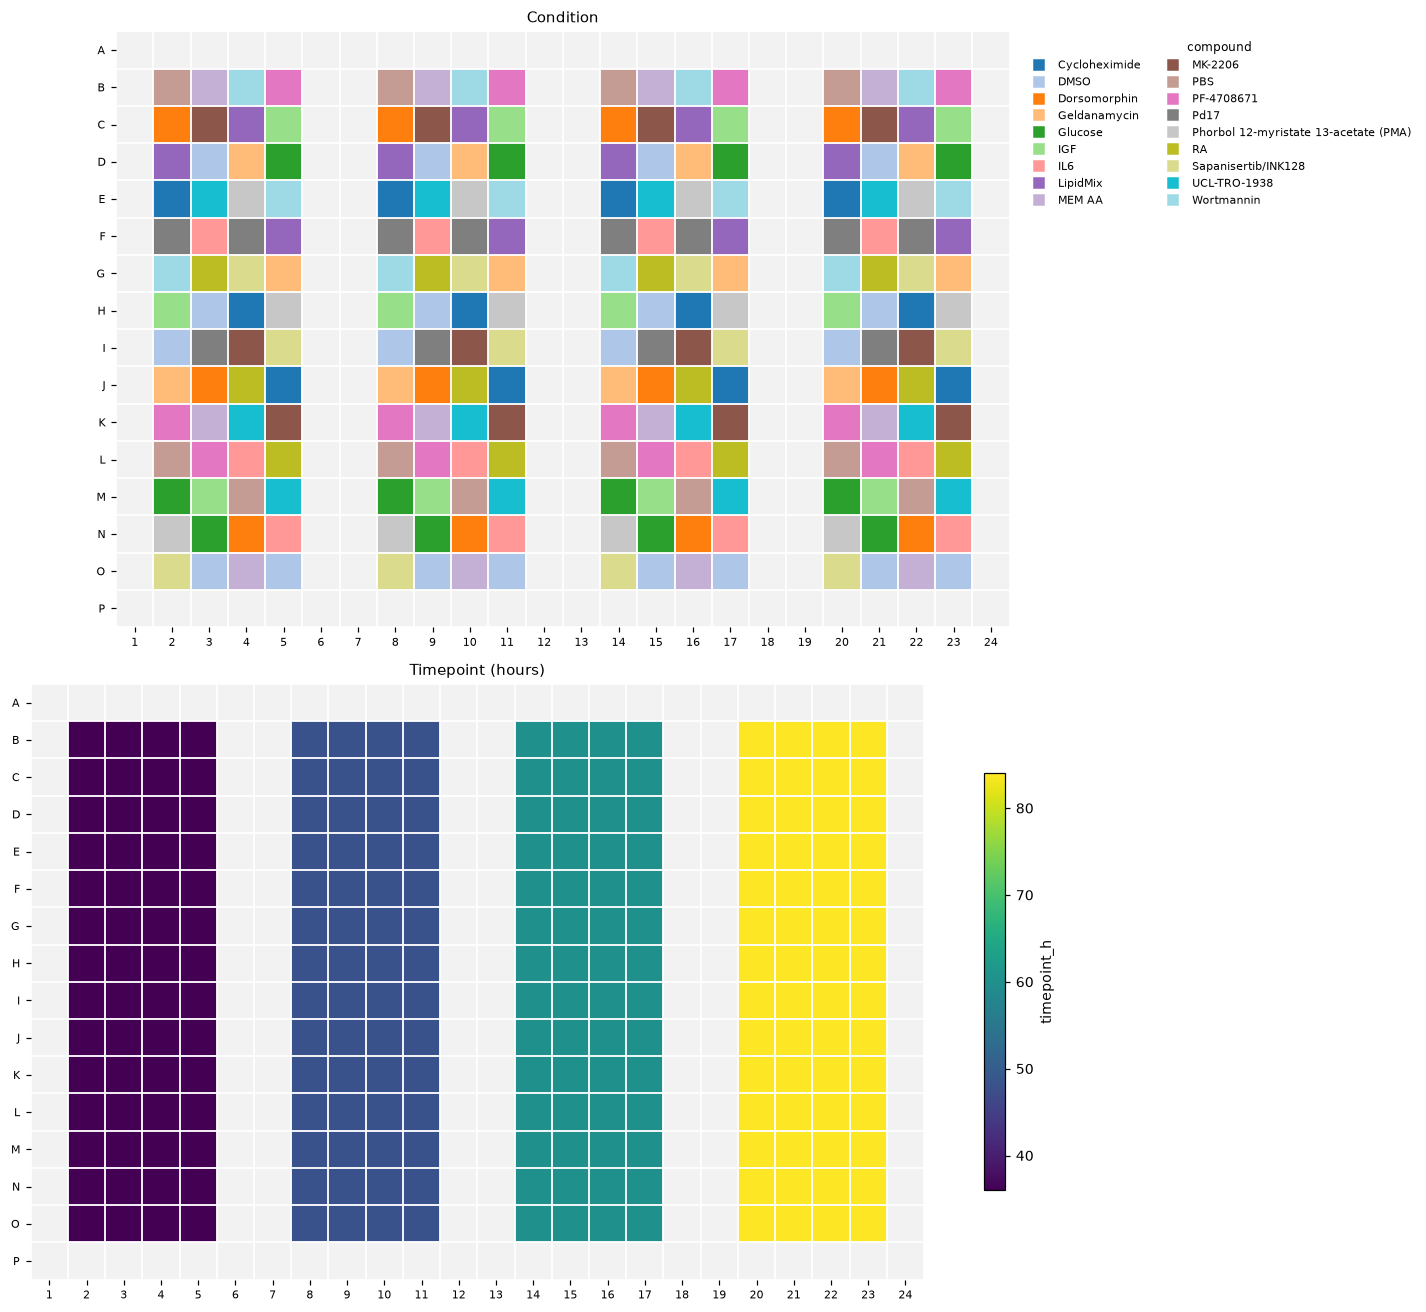

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 12))
plotting.plate_map(wells, "compound", ax=axes[0], title="Condition")
plotting.plate_map(wells, "timepoint_h", ax=axes[1], title="Timepoint (hours)", cmap="viridis")
fig.tight_layout()

Two things are worth reading off those maps.

**The plate is not full.** Rows A and P and the outer columns are empty, and the used
wells sit in four blocks. Edge wells evaporate faster than interior ones, so leaving
the border empty removes a systematic artefact before it happens.

**Timepoint varies by column block, condition varies within a block.** Each block of
four columns is one timepoint; the condition layout repeats identically inside each
block. So timepoint is confounded with plate position by design — worth remembering
when you see a left-to-right gradient in chapter 02.

### The design is deliberately unbalanced

In [6]:
design = wells.pivot_table(
    index=["condition_code", "compound"], columns="timepoint_h",
    values="well", aggfunc="count", observed=True,
).astype(int)
design.sort_values(36, ascending=False).head(6)

,timepoint_h,36,48,60,84
condition_code,compound,,,,
Cnd18,DMSO,5,5,5,5
Cnd10,IL6,3,3,3,3
Cnd8,Glucose,3,3,3,3
Cnd7,LipidMix,3,3,3,3
Cnd6,PF-4708671,3,3,3,3
Cnd5,Sapanisertib/INK128,3,3,3,3


In [7]:
per_group = wells.groupby(["condition_code", "timepoint_h"], observed=True).size()
print("wells per condition per timepoint:", sorted(per_group.unique()))
print("conditions with more than 3:", 
      sorted(per_group[per_group > 3].index.get_level_values(0).unique()))

wells per condition per timepoint: [np.int64(3), np.int64(5)]
conditions with more than 3: ['Cnd18']


**DMSO gets 5 wells per timepoint; everything else gets 3.** That is 17 × 3 + 5 = 56
wells per timepoint, times 4 timepoints, equals 224.

The control is replicated more because every comparison is made against it — the
control's uncertainty enters every single test, so it is worth measuring better.

:::{important}
Write this number down: **3 replicate wells per condition per timepoint** (5 for DMSO).

The feature table has 733,556 rows, but it does not have 733,556 independent
observations. Cells in one well share a well; they were pipetted together, treated
together and imaged together. When you test whether a compound changed something, the
thing you have 3 of is **wells**, not 40,000 of cells. We come back to this, hard, in
chapter 07.
:::

## The staining sheet — the decoder

This is the sheet that matters. Each row is one imaging round; each round has up to
three antibodies plus DAPI, one per colour channel.

In [8]:
stainings = layout.read_stainings(XLSX)
print(f"{len(stainings)} stains over {stainings['round'].nunique()} rounds")
stainings[stainings.marker != "DAPI"][
    ["round", "channel", "marker", "species", "intensity_threshold", "haralick_threshold", "failed"]
]

58 stains over 18 rounds


,round,channel,marker,species,intensity_threshold,haralick_threshold,failed
0,0,Cy5,PDGFRa,Goat,NaN,NaN,True
2,0,FITC,beta-Catenin,Mouse,1000.0,3000.0,False
3,0,Texas Red,Foxo3a,Rabbit,500.0,750.0,False
4,1,Cy5,FGFR1,Rabbit,500.0,2000.0,False
6,1,FITC,Nanog,Goat,1500.0,2000.0,False
7,1,Texas Red,Oct4,Mouse,1000.0,2000.0,False
8,2,Cy5,GATA4,Rat,750.0,3000.0,False
10,2,FITC,p-MyosinIIa,Rabbit,500.0,1000.0,False
11,2,Texas Red,GATA6,Mouse,500.0,1000.0,False
12,3,Cy5,Sox2,Rat,1000.0,2000.0,False


### What a real sheet looks like

Five conventions in this sheet are not documented anywhere. They are exactly the sort
of thing that silently corrupts an analysis, so they are worth naming:

**1. `x` means "no antibody in this slot this round".** Round 21 stained only LAMP1;
the other two channel slots hold `x`. Parse it as a marker name and you get a marker
called "x" in your results.

**2. `failed` means the stain did not work — but the columns still exist.**

In [9]:
stainings[stainings.failed][["round", "channel", "marker", "marker_full"]]

,round,channel,marker,marker_full
0,0,Cy5,PDGFRa,Human PDGF R alpha Antibody
55,28,Cy5,Integrin-b1,Anti-Integrin beta 1 antibody [12G10]


Both of these are still present in the feature table, as 63 columns each, full of
numbers. They are noise with a name, and nothing warns you. We drop them explicitly in
chapter 01.

**3. The same marker can appear twice.** PDGFRα failed in round 0 and was re-stained
successfully in round 18:

In [10]:
stainings[stainings.marker == "PDGFRa"][["round", "channel", "marker", "failed"]]

,round,channel,marker,failed
0,0,Cy5,PDGFRa,True
34,18,FITC,PDGFRa,False


**4. DAPI is in every round.** It is the reference stain — the nuclei have to be found
again after every elution cycle. 18 rounds of DAPI is 25% of the feature table, and 17
of those rounds are near-duplicates of the first.

In [11]:
stainings.channel.value_counts()

channel
DAPI         18
Cy5          17
FITC         13
Texas Red    10
Name: count, dtype: int64

**5. There are two kinds of threshold.** `intensity_threshold` is the level above which
a cell counts as positive for that marker. `haralick_threshold` (written `HLK:3000` in
the sheet) is the level used when computing the texture features. Both were set by eye,
per marker, by the person who did the staining — they are decisions, not measurements,
and they are why the file is named the way it is.

### The decoder itself

Everything above collapses into one lookup: `(channel, round)` → marker.

In [12]:
decoder = stainings.set_index(["channel", "round"])["marker"]
for key in [("Texas Red", 0), ("FITC", 0), ("FITC", 1), ("Cy5", 24), ("FITC", 28)]:
    print(f"  cells_*_{key[0]}_{key[1]:<3} ->  {decoder[key]}")

  cells_*_Texas Red_0   ->  Foxo3a
  cells_*_FITC_0   ->  beta-Catenin
  cells_*_FITC_1   ->  Nanog
  cells_*_Cy5_24  ->  p-AKT
  cells_*_FITC_28  ->  Calreticulin


So `cells_Intensity_mean_intensity_Cy5_24` is the mean intensity of **phospho-AKT
(Ser473)**, and `cells_Texture_LTE_LS_FITC_28` is a texture feature of
**Calreticulin**. That is the whole trick, and chapter 01 applies it to all 4,464
columns at once.

## The four themes

Forty markers is too many to think about at once, so the course groups them into four
biological themes:

In [13]:
for theme in panels.THEMES:
    print(f"{theme:12s} {', '.join(panels.markers(theme))}")

signaling    Foxo3a, Foxo1, FGFR1, PDGFRa, beta-Catenin, YAP1, p-S6, p-AKT, c-Myc, RNAPII-pS5
mechanics    p-MyosinIIa, a-Tubulin, ZO-1, E-cadherin, Fibronectin, LAMA4, LaminA, LaminB1
metabolism   Mitochondria, Pmp70, GRP78, HSP90, Calreticulin, p-S6, p-AKT
organelles   EEA1, GM130, Giantin, LAMP1, DDX6, Calreticulin, GRP78, Pmp70, Mitochondria, LaminA, LaminB1


Plus two groups that are not themes but are needed:

In [14]:
for group in ("identity", "cell_cycle"):
    print(f"{group:12s} {', '.join(panels.markers(group))}")

identity     Oct4, Nanog, Sox2, GATA3, GATA4, GATA6, SOX17
cell_cycle   CyclinA2, p21, Ki67


`identity` holds the lineage transcription factors used to call cell types in chapter
07. `cell_cycle` is a covariate — proliferation changes cell size and marker intensity,
so it is something to check for rather than a result in itself.

:::{important}
**The themes overlap on purpose.** Calreticulin is an ER protein *and* a readout of
metabolic stress. p-S6 and p-AKT sit on the PI3K–mTOR axis, which is both a signaling
pathway and the cell's main metabolic controller.

Forcing each marker into exactly one box would make the code tidier and the biology
wrong. Panels are **sets**, and a marker may belong to several.
:::

In [15]:
overlapping = {}
for theme, markers_ in panels.PANELS.items():
    for marker in markers_:
        overlapping.setdefault(marker, []).append(theme)
{m: t for m, t in sorted(overlapping.items()) if len(t) > 1}

{'Calreticulin': ['metabolism', 'organelles'],
 'GRP78': ['metabolism', 'organelles'],
 'LaminA': ['mechanics', 'organelles'],
 'LaminB1': ['mechanics', 'organelles'],
 'Mitochondria': ['metabolism', 'organelles'],
 'Pmp70': ['metabolism', 'organelles'],
 'p-AKT': ['signaling', 'metabolism'],
 'p-S6': ['signaling', 'metabolism']}

## Write the tidy tables

Finally, save what we parsed. These CSVs are committed to the repository, so the layout
is readable without opening Excel — and so that if the workbook ever changes, the diff
shows exactly what changed.

In [16]:
written = layout.write_metadata(XLSX, XLSX.parent)
for name, path in written.items():
    print(f"  {name:12s} -> {path.name}")

  conditions   -> conditions.csv
  wells        -> wells.csv
  stainings    -> stainings.csv


## Check what we know

Before moving on, assert the numbers. If the workbook is ever replaced, these fail
loudly instead of quietly changing the biology.

In [17]:
assert len(conditions) == 18, "expected 18 conditions"
assert len(wells) == 224, "expected 224 used wells"
assert sorted(wells.timepoint_h.unique()) == [36, 48, 60, 84]
assert stainings["round"].nunique() == 18
assert len(stainings[stainings.marker != "DAPI"]) == 40
assert stainings.failed.sum() == 2
print("Plate layout as expected:")
print(f"  {len(conditions)} conditions, {len(wells)} wells, 4 timepoints")
print(f"  {stainings['round'].nunique()} rounds, 40 stains, {int(stainings.failed.sum())} failed")

Plate layout as expected:
  18 conditions, 224 wells, 4 timepoints
  18 rounds, 40 stains, 2 failed


---

## Exercises

### 1. Where is your favourite marker?

Write a function `find(marker)` that returns the round and channel a marker was imaged
in. Use it to find `LAMP1`, `Sox2` and `GRP78`. Which one is in more than one round?

:::{admonition} Solution
:class: dropdown

```python
def find(marker):
    hit = stainings[stainings.marker == marker]
    return hit[["round", "channel", "failed"]]

for m in ["LAMP1", "Sox2", "GRP78", "PDGFRa"]:
    print(m); print(find(m))
```

`PDGFRa` is the one in two rounds — it failed in round 0 and was re-stained in round
18. `LAMP1` is round 21 / Cy5, `Sox2` round 3 / Cy5, `GRP78` round 18 / Texas Red.
:::

### 2. Which channel did the most work?

Count the non-DAPI stains per channel. Why do you think they are not equal? (Look at
which rounds have only one or two antibodies.)

:::{admonition} Solution
:class: dropdown

```python
non_dapi = stainings[stainings.marker != "DAPI"]
print(non_dapi.channel.value_counts())
print(non_dapi.groupby("round").size().sort_values())
```

Cy5 is used in 17 of 18 rounds, Texas Red in only 10. Rounds 21, 22 and 25 carry a
single antibody each. A 4i round is expensive and can fail, so a round is often run
with fewer antibodies than the maximum — either because a compatible antibody was not
available for that host species, or because the round was a repeat of something that
failed earlier.
:::

### 3. Plate maps that show a problem

Draw a plate map coloured by `condition_code` but for **one timepoint only** (say
84 h). Does the condition layout repeat identically in every block? What would it cost
you if it did *not* — that is, if condition and column were confounded differently at
each timepoint?

:::{admonition} Solution
:class: dropdown

```python
block = wells[wells.timepoint_h == 84]
plotting.plate_map(block, "compound", title="Conditions at 84 h")
```

The layout is identical in every block, which is good: it means condition and *row* are
confounded (each condition sits in fixed rows) but condition and *timepoint* are not.

If the layout differed per block you could not tell a timepoint effect from a position
effect, because each condition would sit in a different part of the plate at each
timepoint. As it is, a position artefact hits every timepoint the same way, so
comparisons *across* timepoints stay interpretable.

The cost of the current design is the other way round: because each condition always
occupies the same rows, a row-wise artefact (an edge effect, a pipetting gradient) is
indistinguishable from a condition effect. That is what chapter 02 checks.
:::

---

**Next:** [01 · Decode and slim](01_decode_and_slim.ipynb) — apply this decoder to all
4,464 feature columns, and turn a 13 GB table into one that loads in seconds.